# 🦷 YOLO26x-seg — DENTALAI **instance** segmentation (per-object polygons)

Unlike the DoubleU-Net recipe (semantic segmentation → **one merged mask per class**), this notebook
trains a **true instance-segmentation** model that predicts **one polygon per object** — every tooth,
every caries, every cavity, every crack is a separate instance with its own polygon. It is trained
**directly on the Supervisely per-instance polygons**, so nothing is merged and no blob-splitting
heuristics are used.

**Model:** `yolo26x-seg.pt` — the **newest (YOLO26, Jan 2026) and largest** Ultralytics seg variant.
On polygon-labeled dental data YOLO11/26 matches Mask R-CNN accuracy at far higher speed. Falls back to
`yolo11x-seg` / `yolov8x-seg` if the installed build lacks YOLO26 weights.

| Setting | Value |
|---|---|
| Task | **Instance segmentation** (polygon per instance) |
| Model | `yolo26x-seg.pt` (fallback yolo11x-seg / yolov8x-seg) |
| Classes | Caries, Cavity, Crack, Tooth — **one multi-class model** |
| Labels | Supervisely polygons → YOLO-seg (`cls x1 y1 … xn yn`, normalized) |
| Input size | `IMGSZ` = **640** (Ultralytics default) |
| Epochs | **100**, no early stopping (`patience=0`) |
| Batch | **16** (RTX 6000 96 GB) |
| Output | per-instance polygons → **Supervisely JSON** + colored overlays |

Everything is written under `output_dentalai_yoloseg/`.

## 1. Environment

In [1]:
!nvidia-smi

Sat Jul  4 07:12:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.71.05              Driver Version: 595.71.05      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    On  |   00000000:01:00.0 Off |                  Off |
| 30%   29C    P8             12W /  400W |       1MiB /  97887MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import sys
!{sys.executable} -m pip install -q --upgrade pip
# ultralytics ships YOLO26/YOLO11/YOLOv8 seg; gdown for the Google-Drive dataset
!{sys.executable} -m pip install -q --upgrade ultralytics gdown opencv-python-headless pyyaml
import torch, ultralytics
print("torch", torch.__version__, "| ultralytics", ultralytics.__version__, "| cuda", torch.cuda.is_available())

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
torch 2.12.0+cu130 | ultralytics 8.4.87 | cuda True


## 2. Imports, seeding & config

In [3]:
import os, json, glob, random, zipfile, tarfile, shutil
import numpy as np
import cv2
import matplotlib.pyplot as plt
from glob import glob as _glob
from tqdm.auto import tqdm
import torch

def seeding(seed=42):
    random.seed(seed); os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
seeding(42)

DEVICE = 0 if torch.cuda.is_available() else "cpu"

GDRIVE_ID   = "1180CBrf1PEVb-DAPpZDjEUs1CNH8lZow"
ROOT_DIR    = "output_dentalai_yoloseg"
DATA_ROOT   = os.path.join(ROOT_DIR, "data")     # raw Supervisely download/extract
YOLO_ROOT   = os.path.join(ROOT_DIR, "yolo_ds")  # converted YOLO-seg dataset

# all classes -> ONE multi-class instance-segmentation model
CLASSES = ["Caries", "Cavity", "Crack", "Tooth"]

IMG_MAX   = 1280       # cap stored image max-side (just above IMGSZ; YOLO resizes to IMGSZ on load)
IMGSZ     = 960       # Ultralytics default input size
EPOCHS    = 100
PATIENCE  = 0         # 0 = disable early stopping -> train the full EPOCHS
BATCH     = 16        # RTX 6000 96GB has ample headroom for x-seg @ 1280
CONF      = 0.25      # inference confidence threshold

# newest+largest first, then graceful fallbacks
MODEL_CANDIDATES = ["yolo26x-seg.pt", "yolo11x-seg.pt", "yolov8x-seg.pt"]

os.makedirs(ROOT_DIR, exist_ok=True)
print("device:", DEVICE, "| working dir:", os.path.abspath(ROOT_DIR))
print("classes:", CLASSES)

device: 0 | working dir: /output_dentalai_yoloseg
classes: ['Caries', 'Cavity', 'Crack', 'Tooth']


## 3. Download DENTALAI (gdown) & locate train/valid/test (img/ + ann/)

In [4]:
import gdown
os.makedirs(DATA_ROOT, exist_ok=True)

def find_dentalai(root):
    for p in glob.glob(os.path.join(root, "**", "train", "img"), recursive=True):
        base = os.path.dirname(os.path.dirname(p))
        if all(os.path.isdir(os.path.join(base, s, k))
               for s in ["train","valid","test"] for k in ["img","ann"]):
            return base
    return None

DATA_PATH = find_dentalai(DATA_ROOT)
if DATA_PATH is None:
    archive = os.path.join(DATA_ROOT, "dentalai_download")
    out = gdown.download(id=GDRIVE_ID, output=archive, quiet=False)
    if out and zipfile.is_zipfile(out):
        with zipfile.ZipFile(out) as z: z.extractall(DATA_ROOT)
    elif out and tarfile.is_tarfile(out):
        with tarfile.open(out) as t: t.extractall(DATA_ROOT)
    else:
        try: gdown.download_folder(id=GDRIVE_ID, output=DATA_ROOT, quiet=False)
        except Exception as e: print("folder download skipped:", e)
    DATA_PATH = find_dentalai(DATA_ROOT)

assert DATA_PATH is not None, "Could not locate DENTALAI (need train/valid/test each with img/ + ann/)."
print("DENTALAI at:", DATA_PATH)
for s in ["train","valid","test"]:
    ni = len(os.listdir(os.path.join(DATA_PATH,s,"img")))
    na = len(os.listdir(os.path.join(DATA_PATH,s,"ann")))
    print(f"  {s:6s} img={ni}  ann={na}")

Downloading...
From (original): https://drive.google.com/uc?id=1180CBrf1PEVb-DAPpZDjEUs1CNH8lZow
From (redirected): https://drive.google.com/uc?id=1180CBrf1PEVb-DAPpZDjEUs1CNH8lZow&confirm=t&uuid=80b54761-b020-4d31-846d-364f16ced7d6
To: /output_dentalai_yoloseg/data/dentalai_download
100%|██████████| 1.17G/1.17G [00:15<00:00, 73.1MB/s]
/tmp/ipykernel_1256/2875409652.py:19: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  with tarfile.open(out) as t: t.extractall(DATA_ROOT)


DENTALAI at: output_dentalai_yoloseg/data
  train  img=1991  ann=1991
  valid  img=254  ann=254
  test   img=250  ann=250


## 3b. Dataset analysis (drives the preprocessing choices)
Scans every annotation to characterize image sizes, class balance, instances/image and object sizes — the facts that justify the preprocessing (downscale + keep-aspect + drop-holes).

In [5]:
import collections
def analyze():
    for split in ["train","valid","test"]:
        anns = sorted(_glob(os.path.join(DATA_PATH, split, "ann", "*.json")))
        ws=[]; hs=[]; ninst=[]; cls=collections.Counter(); vtx=[]; holes=0; areas=collections.defaultdict(list)
        for a in anns:
            d=json.load(open(a)); H=d["size"]["height"]; W=d["size"]["width"]; ws.append(W); hs.append(H)
            ninst.append(len(d["objects"]))
            for o in d["objects"]:
                c=o["classTitle"]; cls[c]+=1; ext=o["points"]["exterior"]; vtx.append(len(ext))
                if o["points"].get("interior"): holes+=1
                if len(ext)>=3:
                    areas[c].append(cv2.contourArea(np.array(ext,np.int32))/(W*H)*100)
        ws=np.array(ws); hs=np.array(hs)
        print(f"=== {split} ({len(anns)} imgs) ===")
        print(f"  W {ws.min()}..{ws.max()} (med {int(np.median(ws))}) | H {hs.min()}..{hs.max()} (med {int(np.median(hs))}) | uniq sizes {len(set(zip(ws.tolist(),hs.tolist())))}")
        print(f"  aspect W/H {(ws/hs).min():.2f}..{(ws/hs).max():.2f} (med {np.median(ws/hs):.2f}) | instances/img {min(ninst)}..{max(ninst)} (mean {np.mean(ninst):.1f})")
        print(f"  class counts {dict(cls)} | polygon verts {min(vtx)}..{max(vtx)} (med {int(np.median(vtx))}) | objects-with-holes {holes}")
        for c in CLASSES:
            if areas[c]:
                v=np.array(areas[c]); print(f"    {c:7s} area% of img: p10={np.percentile(v,10):.3f} med={np.median(v):.3f} p90={np.percentile(v,90):.3f}")
analyze()
print("\nTakeaways -> huge/variable sizes => downscale+keep-aspect (YOLO letterboxes); tiny Caries/Crack "
      "=> small-object regime; near-zero holes => drop interiors; heavy class imbalance (few Cracks).")

=== train (1991 imgs) ===
  W 116..8688 (med 900) | H 77..6000 (med 621) | uniq sizes 1293
  aspect W/H 0.32..3.35 (med 1.50) | instances/img 1..36 (mean 11.5)
  class counts {'Tooth': 17884, 'Caries': 3451, 'Cavity': 1452, 'Crack': 150} | polygon verts 3..222 (med 23) | objects-with-holes 1
    Caries  area% of img: p10=0.002 med=0.027 p90=0.432
    Cavity  area% of img: p10=0.069 med=0.785 p90=7.652
    Crack   area% of img: p10=0.097 med=0.646 p90=2.650
    Tooth   area% of img: p10=0.307 med=1.256 p90=6.578
=== valid (254 imgs) ===
  W 200..8192 (med 3000) | H 125..6000 (med 2164) | uniq sizes 186
  aspect W/H 0.45..2.68 (med 1.50) | instances/img 2..32 (mean 12.4)
  class counts {'Tooth': 2653, 'Crack': 16, 'Caries': 328, 'Cavity': 159} | polygon verts 4..118 (med 22) | objects-with-holes 0
    Caries  area% of img: p10=0.002 med=0.023 p90=0.345
    Cavity  area% of img: p10=0.027 med=0.293 p90=6.619
    Crack   area% of img: p10=0.113 med=0.396 p90=1.473
    Tooth   area% of img:

## 4. Convert Supervisely polygons → YOLO-seg labels (one line per instance)
Each object polygon becomes one YOLO-seg instance: `cls x1 y1 x2 y2 … xn yn` (normalized 0–1, clamped). Images are downscaled (max-side `IMG_MAX`, **INTER_AREA**, aspect kept) to speed training — normalized labels are resolution-independent so they stay valid. Holes/interiors are dropped (YOLO-seg is single-ring; only 1 object in the whole dataset has a hole). Degenerate polygons (<3 pts or ~0 area) are skipped (~0.003% of objects). No CLAHE/normalization is baked in — YOLO does `/255` + its own aug.

In [6]:
def ann_to_img_path(ann_path, split):
    name = os.path.basename(ann_path)[:-5]   # strip ".json"
    return os.path.join(DATA_PATH, split, "img", name)

def _norm_flat(points, W, H):
    out = []
    for x, y in points:
        out.append(min(max(x / W, 0.0), 1.0))
        out.append(min(max(y / H, 0.0), 1.0))
    return out

def convert_split(split):
    img_out = os.path.join(YOLO_ROOT, "images", split); os.makedirs(img_out, exist_ok=True)
    lbl_out = os.path.join(YOLO_ROOT, "labels", split); os.makedirs(lbl_out, exist_ok=True)
    anns = sorted(_glob(os.path.join(DATA_PATH, split, "ann", "*.json")))
    n_img = 0; n_inst = {c: 0 for c in CLASSES}; n_skip = 0
    for ann_path in tqdm(anns, desc=f"convert {split}", leave=False):
        d = json.load(open(ann_path)); H = d["size"]["height"]; W = d["size"]["width"]
        ip = ann_to_img_path(ann_path, split); img = cv2.imread(ip, cv2.IMREAD_COLOR)
        if img is None:
            continue
        stem = os.path.splitext(os.path.basename(ip))[0]
        h, w = img.shape[:2]; scale = min(1.0, IMG_MAX / max(h, w))
        if scale < 1.0:
            img = cv2.resize(img, (int(round(w*scale)), int(round(h*scale))), interpolation=cv2.INTER_AREA)
        cv2.imwrite(os.path.join(img_out, stem + ".jpg"), img, [cv2.IMWRITE_JPEG_QUALITY, 95])
        lines = []
        for o in d["objects"]:
            c = o["classTitle"]
            if c not in CLASSES:
                continue
            ext = o["points"]["exterior"]
            if len(ext) < 3:                                          # not a polygon
                n_skip += 1; continue
            if cv2.contourArea(np.array(ext, np.int32)) < 1.0:        # degenerate (zero-area) polygon
                n_skip += 1; continue
            coords = _norm_flat(ext, W, H)
            lines.append(str(CLASSES.index(c)) + " " + " ".join(f"{v:.6f}" for v in coords))
            n_inst[c] += 1
        with open(os.path.join(lbl_out, stem + ".txt"), "w") as f:
            f.write("\n".join(lines))
        n_img += 1
    return n_img, n_inst, n_skip

need = not all(os.path.isdir(os.path.join(YOLO_ROOT, "images", s)) and
               len(_glob(os.path.join(YOLO_ROOT, "images", s, "*.jpg"))) > 0
               for s in ["train","valid","test"])
if need:
    for s in ["train","valid","test"]:
        ni, inst, nsk = convert_split(s)
        print(f"{s:6s}: {ni} images | instances " + ", ".join(f"{k}={v}" for k,v in inst.items()) +
              f" | skipped degenerate={nsk}")
else:
    print("yolo_ds/ already converted — skipping.")

# data.yaml
yaml_path = os.path.join(YOLO_ROOT, "dentalai.yaml")
with open(yaml_path, "w") as f:
    f.write(f"path: {os.path.abspath(YOLO_ROOT)}\n")
    f.write("train: images/train\nval: images/valid\ntest: images/test\n")
    f.write("names:\n")
    for i, c in enumerate(CLASSES):
        f.write(f"  {i}: {c}\n")
print("wrote", yaml_path)
print(open(yaml_path).read())

convert train:   0%|          | 0/1991 [00:00<?, ?it/s]

train : 1991 images | instances Caries=3451, Cavity=1452, Crack=150, Tooth=17884 | skipped degenerate=0


convert valid:   0%|          | 0/254 [00:00<?, ?it/s]

valid : 254 images | instances Caries=328, Cavity=159, Crack=16, Tooth=2653 | skipped degenerate=0


convert test:   0%|          | 0/250 [00:00<?, ?it/s]

test  : 250 images | instances Caries=433, Cavity=170, Crack=14, Tooth=2194 | skipped degenerate=0
wrote output_dentalai_yoloseg/yolo_ds/dentalai.yaml
path: /output_dentalai_yoloseg/yolo_ds
train: images/train
val: images/valid
test: images/test
names:
  0: Caries
  1: Cavity
  2: Crack
  3: Tooth



## 4b. Sanity check — round-tripped labels on the HARDEST samples
Draws the converted YOLO-seg polygons back on the preprocessed images for the worst cases (largest photo → biggest downscale, many tiny Caries, a rare Crack). If polygons still hug the right structures here, the downscale+normalize preprocessing is correct everywhere.

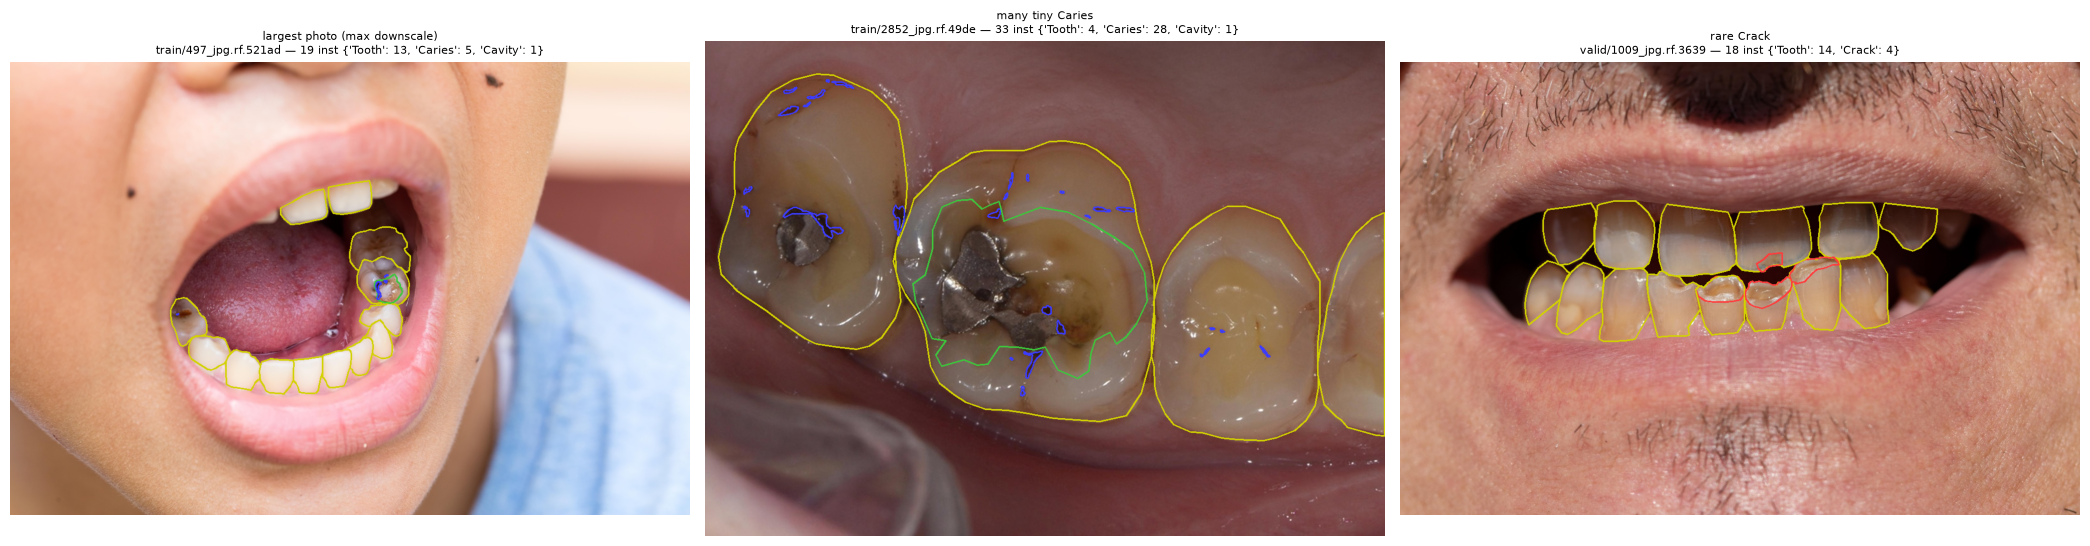

saved output_dentalai_yoloseg/label_sanity_check.png


In [7]:
_COLORS = {"Caries":(255,60,60), "Cavity":(60,200,60), "Crack":(60,60,255), "Tooth":(0,210,210)}

def draw_yolo_label(img_path, lbl_path):
    img = cv2.imread(img_path); H, W = img.shape[:2]; ov = img.copy()
    thick = max(1, H // 400)
    if os.path.exists(lbl_path):
        for line in open(lbl_path):
            p = line.split()
            if len(p) < 7: continue
            cid = int(p[0]); cls = CLASSES[cid]
            xy = np.array(p[1:], np.float32).reshape(-1, 2) * np.array([W, H], np.float32)
            cv2.polylines(ov, [xy.astype(np.int32)], True, _COLORS.get(cls,(255,255,0)), thick)
    return cv2.cvtColor(ov, cv2.COLOR_BGR2RGB)

# pick hard/diverse samples from the raw annotations (across all splits)
def _stem_paths(split, stem):
    return (os.path.join(YOLO_ROOT,"images",split,stem+".jpg"),
            os.path.join(YOLO_ROOT,"labels",split,stem+".txt"))
cand=[]
for split in ["train","valid","test"]:
    for a in _glob(os.path.join(DATA_PATH, split, "ann", "*.json")):
        d=json.load(open(a)); W=d["size"]["width"]; H=d["size"]["height"]
        ctr=collections.Counter(o["classTitle"] for o in d["objects"])
        cand.append((split, os.path.splitext(os.path.basename(a)[:-5])[0], W*H, ctr))
picks = {
    "largest photo (max downscale)": max(cand, key=lambda r: r[2]),
    "many tiny Caries":              max(cand, key=lambda r: r[3].get("Caries",0)),
    "rare Crack":                    max(cand, key=lambda r: r[3].get("Crack",0)),
}
fig, ax = plt.subplots(1, len(picks), figsize=(7*len(picks), 7))
if len(picks) == 1: ax = [ax]
for a,(title,(split,stem,_,ctr)) in zip(ax, picks.items()):
    ip, lp = _stem_paths(split, stem)
    ninst = sum(1 for _ in open(lp)) if os.path.exists(lp) else 0
    if os.path.exists(ip):
        a.imshow(draw_yolo_label(ip, lp))
    a.set_title(f"{title}\n{split}/{stem[:16]} — {ninst} inst {dict(ctr)}", fontsize=8); a.axis("off")
plt.tight_layout(); plt.savefig(os.path.join(ROOT_DIR, "label_sanity_check.png"), dpi=110); plt.show()
print("saved", os.path.join(ROOT_DIR, "label_sanity_check.png"))

## 5. Train YOLO26x-seg (newest + largest, with fallback)

In [8]:
from ultralytics import YOLO
        
def load_seg_model():
    last = None
    for w in MODEL_CANDIDATES:
        try:
            m = YOLO(w); print("loaded seg weights:", w); return m, w
        except Exception as e:
            print("  unavailable:", w, "->", str(e)[:120]); last = e
    raise RuntimeError(f"No seg weights could be loaded from {MODEL_CANDIDATES}: {last}")

model, MODEL_NAME = load_seg_model()

results = model.train(
    data=yaml_path,
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    patience=PATIENCE,
    device=DEVICE,
    project=ROOT_DIR,
    name="train",
    seed=42,
    exist_ok=True,
    val=True,
    plots=True,
)
BEST_PT = os.path.join(ROOT_DIR, "train", "weights", "best.pt")
print("best weights ->", BEST_PT, "| exists:", os.path.exists(BEST_PT))

loaded seg weights: yolo26x-seg.pt
Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.12.0+cu130 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Workstation Edition, 97250MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=output_dentalai_yoloseg/yolo_ds/dentalai.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26x-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=trai

## 6. Evaluate on the TEST split — box + MASK mAP (per class)

In [19]:
!{sys.executable} -m pip install -q --upgrade pandas
import pandas as pd
BEST_PT = str(model.trainer.save_dir / "weights" / "best.pt")
print(BEST_PT, os.path.exists(BEST_PT))
best = YOLO(BEST_PT)
metrics = best.val(data=yaml_path, split="test", imgsz=IMGSZ, device=DEVICE,
                   project=ROOT_DIR, name="test_eval", exist_ok=True, plots=True)

print("\n================ TEST — instance-segmentation metrics ================")
print(f"Mask  mAP50-95: {metrics.seg.map:.4f} | mAP50: {metrics.seg.map50:.4f}")
print(f"Box   mAP50-95: {metrics.box.map:.4f} | mAP50: {metrics.box.map50:.4f}")
try:
    print("\nPer-class mask mAP50-95:")
    for i, c in enumerate(CLASSES):
        print(f"  {c:8s}: {metrics.seg.maps[i]:.4f}")
except Exception as e:
    print("per-class breakdown unavailable:", e)

import pandas as pd
pd.DataFrame([{
    "mask_mAP50-95": metrics.seg.map, "mask_mAP50": metrics.seg.map50,
    "box_mAP50-95": metrics.box.map,  "box_mAP50": metrics.box.map50,
    "model": MODEL_NAME,
}]).to_csv(os.path.join(ROOT_DIR, "test_summary.csv"), index=False)
print("saved", os.path.join(ROOT_DIR, "test_summary.csv"))

/runs/segment/output_dentalai_yoloseg/train/weights/best.pt True
Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.12.0+cu130 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Workstation Edition, 97250MiB)
YOLO26x-seg summary (fused): 207 layers, 62,731,352 parameters, 0 gradients, 313.0 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3168.0±3556.3 MB/s, size: 73.3 KB)
val: Scanning /output_dentalai_yoloseg/yolo_ds/labels/test.cache... 250 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 250/250 69.9Mit/s 0.0s
val: /output_dentalai_yoloseg/yolo_ds/images/test/1669_jpg.rf.1ece4d3bb8d8f77fd498449fbb765418.jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 4.9it/s 3.3s0.2s
                   all        250       2810      0.728      0.498      0.521       0.36      0.714      0.482      0.503      0.318
                Caries        124        433      0.54

## 7. Inference → per-instance polygons → **Supervisely JSON** + overlays
`results.masks.xy` gives each instance's polygon in image-pixel coords. We save one Supervisely polygon object per instance (same format as the input labels) plus a colored overlay.

In [15]:
def polys_to_supervisely(objs, H, W):
    """objs = [(classTitle, exterior[[x,y]..]), ...] -> Supervisely annotation dict."""
    objects = [{
        "classTitle": c, "geometryType": "polygon",
        "points": {"exterior": [[int(round(x)), int(round(y))] for x, y in ext], "interior": []},
    } for c, ext in objs]
    return {"description": "", "size": {"height": int(H), "width": int(W)}, "objects": objects}

def draw_pred(img, objs):
    ov = img.copy()
    for k, (c, ext) in enumerate(objs):
        color = _COLORS.get(c, (255, 255, 0)); pts = np.array(ext, np.int32)
        cv2.polylines(ov, [pts], True, color, 2)
        cx, cy = pts.mean(0).astype(int)
        cv2.putText(ov, f"{c[:3]}{k+1}", (int(cx), int(cy)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    return ov

pred_dir  = os.path.join(ROOT_DIR, "predictions")
poly_dir  = os.path.join(pred_dir, "poly_json");  os.makedirs(poly_dir, exist_ok=True)
ovl_dir   = os.path.join(pred_dir, "overlay");     os.makedirs(ovl_dir, exist_ok=True)

test_imgs = sorted(_glob(os.path.join(YOLO_ROOT, "images", "test", "*.jpg")))
inst_total = {c: 0 for c in CLASSES}
for ip in tqdm(test_imgs, desc="predict test"):
    img = cv2.imread(ip); H, W = img.shape[:2]
    r = best(ip, imgsz=IMGSZ, conf=CONF, device=DEVICE, verbose=False)[0]
    objs = []
    if r.masks is not None:
        clss = r.boxes.cls.cpu().numpy().astype(int)
        for xy, cid in zip(r.masks.xy, clss):
            if len(xy) >= 3:
                objs.append((CLASSES[cid], xy.tolist())); inst_total[CLASSES[cid]] += 1
    stem = os.path.splitext(os.path.basename(ip))[0]
    with open(os.path.join(poly_dir, stem + ".json"), "w") as f:
        json.dump(polys_to_supervisely(objs, H, W), f)
    cv2.imwrite(os.path.join(ovl_dir, stem + ".jpg"), draw_pred(img, objs))

print("predicted instances (test):", inst_total)
print("polygons ->", os.path.abspath(poly_dir))
print("overlays ->", os.path.abspath(ovl_dir))

predict test:   0%|          | 0/250 [00:00<?, ?it/s]

predicted instances (test): {'Caries': 288, 'Cavity': 142, 'Crack': 1, 'Tooth': 2517}
polygons -> /output_dentalai_yoloseg/predictions/poly_json
overlays -> /output_dentalai_yoloseg/predictions/overlay


## 8. Preview predicted per-instance polygons

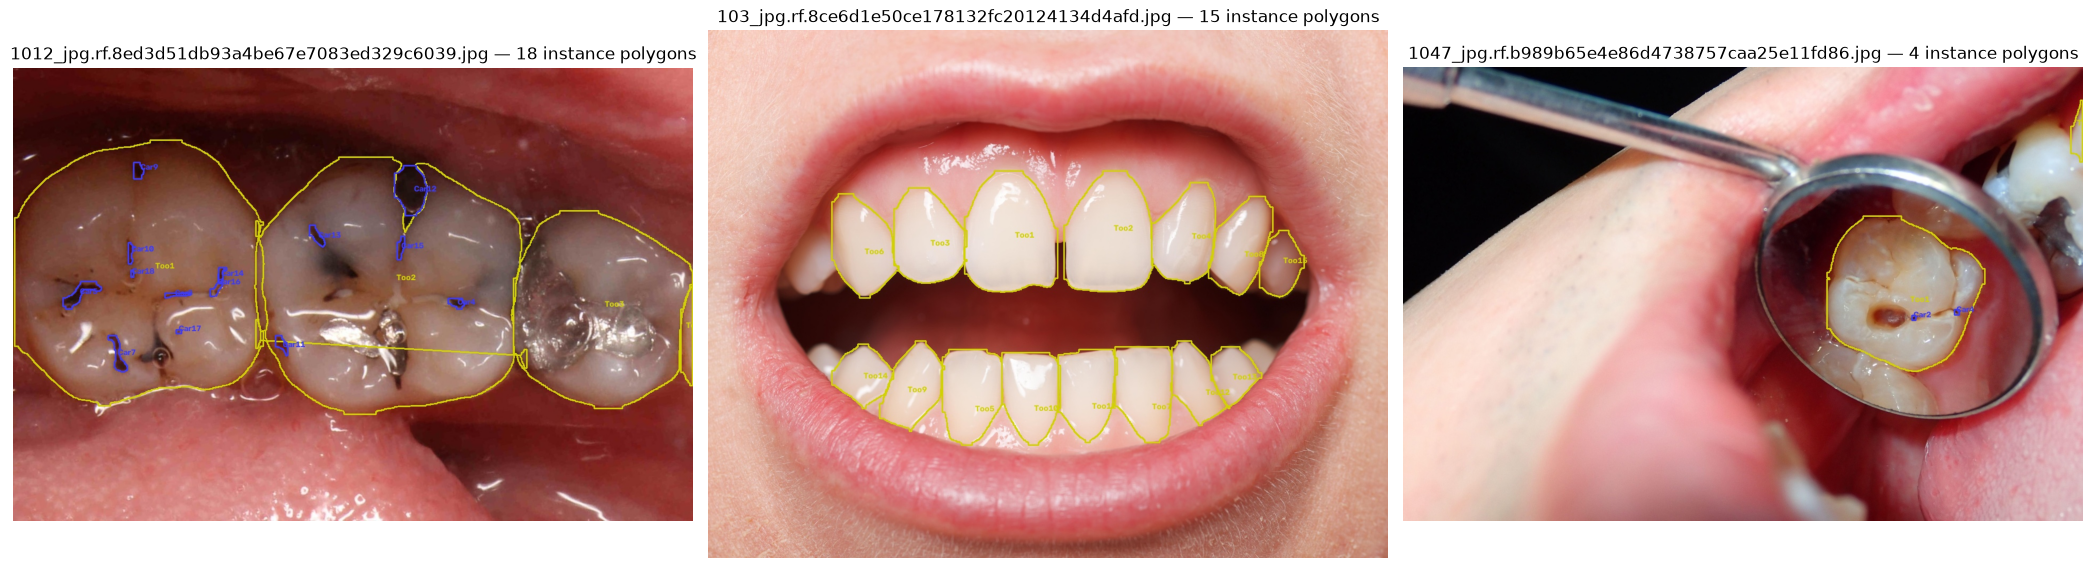

In [16]:
ovs = sorted(_glob(os.path.join(ovl_dir, "*.jpg")))[:3]
if ovs:
    fig, ax = plt.subplots(1, len(ovs), figsize=(7*len(ovs), 7))
    if len(ovs) == 1: ax = [ax]
    for a, op in zip(ax, ovs):
        jp = os.path.join(poly_dir, os.path.splitext(os.path.basename(op))[0] + ".json")
        n = len(json.load(open(jp))["objects"]) if os.path.exists(jp) else 0
        a.imshow(cv2.cvtColor(cv2.imread(op), cv2.COLOR_BGR2RGB))
        a.set_title(f"{os.path.basename(op)} — {n} instance polygons"); a.axis("off")
    plt.tight_layout(); plt.show()
else:
    print("no overlays found")

## Outputs (under `output_dentalai_yoloseg/`)
- `data/` — raw DENTALAI download (Supervisely `img/` + `ann/`)
- `yolo_ds/` — converted dataset: `images/{train,valid,test}`, `labels/{...}` (YOLO-seg), `dentalai.yaml`
- `label_sanity_check.png` — converted polygons drawn back on images
- `train/` — Ultralytics run: `weights/best.pt`, curves, confusion matrix, sample batches
- `test_eval/` — validation-on-test plots
- `test_summary.csv` — box + **mask** mAP (50 and 50-95)
- `predictions/poly_json/*.json` — **per-instance polygons in Supervisely format** (one object per instance)
- `predictions/overlay/*.jpg` — colored per-instance polygon overlays

### Why this (vs the DoubleU-Net builder)
- DoubleU-Net = **semantic** segmentation → one merged mask per class (teeth fused into one blob).
- **YOLO26x-seg = instance** segmentation → **one polygon per object**, trained directly on the
  Supervisely per-instance polygons. Newest + largest seg model; matches Mask R-CNN accuracy faster.

**Run config:** `yolo26x-seg`, `imgsz=640` (Ultralytics default), `epochs=100`, `patience=0` (no early
stop), `batch=16`. **Tuning:** lower `CONF` to catch more faint lesions; `Crack` (rarest class) is the
hardest — watch its per-class mask mAP. If small-crack/caries recall is weak, bump `imgsz` to 960 or 1280.